In [153]:
import pandas as pd
from sklearn.model_selection import StratifiedGroupKFold
import librosa
from scipy.signal import convolve2d
import numpy as np
import matplotlib.pyplot as plt

from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import MinMaxScaler
from sklearn.pipeline import Pipeline

In [154]:
df = pd.read_pickle('RomanceDigitData.pkl')
df.head()

,signal_data,language,speaker,label,gender,c,length
0,"[0.0, 3.0517578125e-05, -6.103515625e-05, -3.0...",PO,A,1,M,c,7101
1,"[0.0, 0.0, 3.0517578125e-05, 0.0, 6.103515625e...",PO,A,2,M,c,12861
2,"[0.0, 0.0, 0.0, -3.0517578125e-05, 0.0, 3.0517...",PO,A,3,M,c,10557
3,"[0.0, 0.0, -3.0517578125e-05, -3.0517578125e-0...",PO,A,4,M,c,10941
4,"[-3.0517578125e-05, 3.0517578125e-05, 0.0, 0.0...",PO,A,5,M,c,14397


In [155]:
df['language'].unique()

<StringArray>
['PO', 'IT', 'SI', 'FR', 'SA']
Length: 5, dtype: str

In [156]:
df['language'].value_counts()

language
FR    60
IT    50
SA    46
SI    38
PO    25
Name: count, dtype: int64

In [157]:
from sklearn.model_selection import StratifiedShuffleSplit

# Simply split based on the language column
sss = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)

for train_index, test_index in sss.split(df, df['language']):
    train_set = df.iloc[train_index]
    test_set = df.iloc[test_index]

print(f"Lang Train distribution:\n{train_set['language'].value_counts()}")
print(f"Lang Test distribution:\n{test_set['language'].value_counts()}")

print(f"Num Train distribution:\n{train_set['label'].value_counts()}")
print(f"Num Test distribution:\n{test_set['label'].value_counts()}")

Lang Train distribution:
language
FR    48
IT    40
SA    37
SI    30
PO    20
Name: count, dtype: int64
Lang Test distribution:
language
FR    12
IT    10
SA     9
SI     8
PO     5
Name: count, dtype: int64
Num Train distribution:
label
2     21
4     20
7     19
5     18
1     18
6     17
9     16
8     16
3     15
10    15
Name: count, dtype: int64
Num Test distribution:
label
8     7
3     7
9     6
1     5
5     5
6     4
7     3
10    3
4     2
2     2
Name: count, dtype: int64


In [158]:
for num in sorted(train_set['label'].unique()):
    for lang in sorted(train_set['language'].unique()):
        # Filter the dataframe for the specific language AND label
        count = len(train_set[(train_set['language'] == lang) & (train_set['label'] == num)])
        print(f"Language: {lang}, Label: {num}, Count: {count}")

Language: FR, Label: 1, Count: 4
Language: IT, Label: 1, Count: 5
Language: PO, Label: 1, Count: 2
Language: SA, Label: 1, Count: 3
Language: SI, Label: 1, Count: 4
Language: FR, Label: 2, Count: 5
Language: IT, Label: 2, Count: 5
Language: PO, Label: 2, Count: 3
Language: SA, Label: 2, Count: 4
Language: SI, Label: 2, Count: 4
Language: FR, Label: 3, Count: 6
Language: IT, Label: 3, Count: 2
Language: PO, Label: 3, Count: 2
Language: SA, Label: 3, Count: 3
Language: SI, Label: 3, Count: 2
Language: FR, Label: 4, Count: 5
Language: IT, Label: 4, Count: 4
Language: PO, Label: 4, Count: 2
Language: SA, Label: 4, Count: 5
Language: SI, Label: 4, Count: 4
Language: FR, Label: 5, Count: 6
Language: IT, Label: 5, Count: 4
Language: PO, Label: 5, Count: 1
Language: SA, Label: 5, Count: 4
Language: SI, Label: 5, Count: 3
Language: FR, Label: 6, Count: 5
Language: IT, Label: 6, Count: 2
Language: PO, Label: 6, Count: 2
Language: SA, Label: 6, Count: 5
Language: SI, Label: 6, Count: 3
Language: 

In [159]:

# # Stratify by language, Group by speaker ONLY
# sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=555)


# from sklearn.model_selection import StratifiedGroupKFold

# # Stratify by 'language', group by 'speaker'
# sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)

# # The 'groups' parameter now only uses the 'speaker' column
# for train_index, test_index in sgkf.split(df, df['language'], groups=df['speaker']):

#     train_set = df.iloc[train_index]
#     test_set = df.iloc[test_index]
#     break

# # Optional: Verification
# print(f"Unique labels in Train: {train_set['label'].unique()}, total = {len(train_set['label'].unique())}")
# print(f"Unique labels in Test: {test_set['label'].unique()}, total = {len(test_set['label'].unique())}")

# print(f"Unique lang in Train: {train_set['language'].unique()}, total = {len(train_set['language'].unique())}")
# print(f"Unique lang in Test: {test_set['language'].unique()}, total = {len(test_set['language'].unique())}")

# print("Training set distribution:")
# print(train_set['language'].value_counts())

# # Check language distribution in testing set
# print("\nTesting set distribution:")
# print(test_set['language'].value_counts())

In [160]:
train_set[train_set['language'] == 'PO']

,signal_data,language,speaker,label,gender,c,length
12,"[0.0, 0.0, 0.0, 0.0, 3.0517578125e-05, 3.05175...",PO,B,3,F,c,9401
17,"[0.0, 0.0, 0.0, 3.0517578125e-05, 3.0517578125...",PO,B,8,F,c,8801
24,"[-0.000213623046875, -0.000152587890625, -0.00...",PO,C,9,F,c,9393
10,"[0.0, -3.0517578125e-05, 0.0, 0.0, 3.051757812...",PO,B,1,F,c,6801
20,"[0.0001220703125, 0.0001220703125, 0.0, 3.0517...",PO,C,1,F,c,7665
11,"[0.0, -3.0517578125e-05, -3.0517578125e-05, 0....",PO,B,2,F,c,13201
13,"[0.0, 0.0, -3.0517578125e-05, 0.0, 3.051757812...",PO,B,4,F,c,10601
21,"[0.0, 0.0, -3.0517578125e-05, 0.0, 0.0, 0.0, -...",PO,C,10,F,c,8241
7,"[0.0, 0.0, 0.0, -3.0517578125e-05, 0.0, -3.051...",PO,A,8,M,c,19255
19,"[-3.0517578125e-05, -3.0517578125e-05, -3.0517...",PO,C,2,F,c,9969


In [161]:
from sklearn.preprocessing import LabelEncoder

# 1. Initialize the encoder
encoder = LabelEncoder()

# 2. Fit on the entire dataset (or just training set) to ensure all labels are captured
# It is best practice to fit on the training set to avoid data leakage
encoder.fit(train_set['language'])

# 3. Transform both your training and testing labels
train_set['language_encoded'] = encoder.transform(train_set['language'])
test_set['language_encoded'] = encoder.transform(test_set['language'])

# Keep the mapping for later when you need to interpret your predictions
language_mapping = dict(zip(encoder.classes_, encoder.transform(encoder.classes_)))
print(f"Language Mapping: {language_mapping}")

Language Mapping: {'FR': np.int64(0), 'IT': np.int64(1), 'PO': np.int64(2), 'SA': np.int64(3), 'SI': np.int64(4)}


In [162]:
test_set

,signal_data,language,speaker,label,gender,c,length,language_encoded
104,"[-0.0234375, -0.015625, -0.0078125, -0.0078125...",SI,C,8,M,c,7500,4
218,"[-0.14410400390625, -0.144775390625, -0.145050...",SA,E,9,F,c,11251,3
64,"[-0.0078125, -0.0078125, -0.0078125, 0.0, -0.0...",IT,D,9,F,c,24456,1
6,"[-3.0517578125e-05, 0.0, 0.0, -3.0517578125e-0...",PO,A,7,M,c,10393,2
127,"[-0.000152587890625, 0.0001220703125, 0.000152...",FR,B,4,F,c,7001,0
164,"[-3.0517578125e-05, 0.0, 3.0517578125e-05, -6....",FR,F,1,F,c,6501,0
0,"[0.0, 3.0517578125e-05, -6.103515625e-05, -3.0...",PO,A,1,M,c,7101,2
59,"[-0.015625, -0.0078125, -0.0078125, -0.0078125...",IT,D,4,F,c,12001,1
4,"[-3.0517578125e-05, 3.0517578125e-05, 0.0, 0.0...",PO,A,5,M,c,14397,2
38,"[-0.03369140625, -0.039459228515625, -0.032470...",IT,B,3,F,c,3100,1


In [163]:

# Define a function to resample your audio data
def resample_signal(signal, orig_sr=16000, target_sr=8000):
    # Ensure signal is a numpy array
    signal = np.array(signal)
    return librosa.resample(y=signal, orig_sr=orig_sr, target_sr=target_sr)

# Apply the function to the signal_data column
train_set['signal_data_8k'] = train_set['signal_data'].apply(lambda x: resample_signal(x))
test_set['signal_data_8k'] = test_set['signal_data'].apply(lambda x: resample_signal(x))


# Update sample rate reference
target_sr = 8000

In [164]:
def get_spectrogram_zones(signal, sr=8000, n_fft=256, hop_length=80):
    """
    Generates spectrogram and segments it into 10 frequency zones.
    Parameters match: 8kHz signal, 256-point DFT, 10ms frame rate[cite: 87].
    """
    # Generate STFT with Hanning window [cite: 87]
    D = librosa.stft(signal, n_fft=n_fft, hop_length=hop_length, 
                     win_length=n_fft, window='hann')
    spectrogram = np.abs(D) # Magnitude spectrogram
    
    # Linear Zoning: Segment into 10 frequency sub-bands [cite: 88, 89]
    # The STFT output has (n_fft // 2 + 1) frequency bins = 129 bins
    # We split the 129 bins into 10 zones
    num_zones = 10
    bins_per_zone = spectrogram.shape[0] // num_zones
    
    zones = []
    for i in range(num_zones):
        start_bin = i * bins_per_zone
        # Ensure the last zone captures remaining bins
        end_bin = (i + 1) * bins_per_zone if i < num_zones - 1 else spectrogram.shape[0]
        zones.append(spectrogram[start_bin:end_bin, :])
        
    return zones

# Apply to your train and test sets
# This creates a new column containing a list of 10 arrays (one per zone)
train_set['spectrogram_zones'] = train_set['signal_data_8k'].apply(
    lambda x: get_spectrogram_zones(x, sr=target_sr)
)
test_set['spectrogram_zones'] = test_set['signal_data_8k'].apply(
    lambda x: get_spectrogram_zones(x, sr=target_sr)
)

In [165]:
train_set['spectrogram_zones'].iloc[0]

[array([[1.21443445e-02, 7.47349523e-03, 2.08044112e-03, 1.79624054e-02,
         1.35785252e-04, 1.90385194e-02, 2.15850348e-02, 2.50372168e-02,
         3.75873190e-02, 6.59327759e-02, 8.02098200e-02, 1.72822664e-02,
         6.42320455e-02, 7.79427804e-02, 1.82469894e-02, 2.14660399e-02,
         2.40422944e-02, 2.17021537e-02, 1.28334974e-02, 5.44782577e-03,
         1.74990134e-02, 3.20562277e-02, 1.63434300e-03, 1.08862617e-02,
         5.78624959e-03, 2.16230334e-02, 1.82689658e-02, 2.40247128e-03,
         9.90963941e-03, 1.31307434e-02, 2.82216470e-02, 3.96160558e-02,
         3.41189912e-02, 2.09086936e-02, 1.02142499e-02, 1.05067431e-02,
         1.79633401e-02, 3.10376933e-02, 3.47181680e-02, 7.64529565e-04,
         4.25522607e-03, 1.65857311e-02, 6.41540405e-03, 1.99335611e-02,
         1.56146467e-02, 1.93669437e-02, 2.83880295e-02, 8.35783945e-03,
         9.40333116e-03, 3.26004766e-03, 2.25398882e-03, 3.09227002e-03,
         5.38498529e-04, 1.59051649e-03, 8.11939089

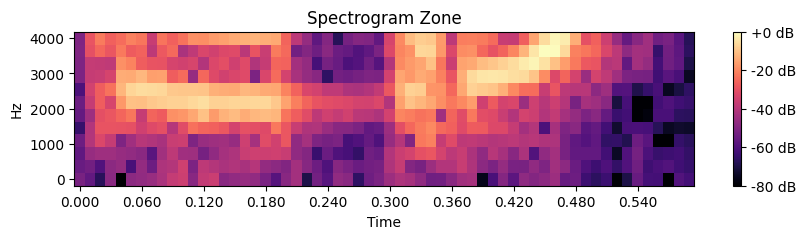

In [166]:


def plot_spectrogram_zone(zone_data, sr=8000, hop_length=80):
    plt.figure(figsize=(10, 2)) # Smaller height for a zone
    # Use amplitude_to_db for better visualization
    # We remove 'y_axis' or set it to 'linear' carefully since this is only a band
    db_spec = librosa.amplitude_to_db(zone_data, ref=np.max)
    librosa.display.specshow(db_spec, sr=sr, hop_length=hop_length, 
                             x_axis='time', y_axis='linear')
    plt.colorbar(format='%+2.0f dB')
    plt.title('Spectrogram Zone')
    plt.show()

# Usage: 
# Access the list of zones for the first sample, then pick the first zone (index 0)
sample_zones = train_set['spectrogram_zones'].iloc[0]
plot_spectrogram_zone(sample_zones[0])

In [167]:
test_set['spectrogram_zones'].iloc[0]

[array([[5.72883012e-01, 1.08563002e+00, 8.63559959e-01, 6.15403438e-01,
         2.67599013e-01, 8.87545579e-02, 4.94531877e-03, 7.53875265e-01,
         5.79850277e-01, 1.96575178e-01, 1.51424711e-01, 8.27392084e-01,
         1.46933780e+00, 1.58877574e+00, 2.36633764e+00, 2.65699739e+00,
         1.31604484e+00, 3.29785560e-01, 8.86219879e-01, 1.02405035e+00,
         9.66818956e-01, 9.99815335e-01, 9.59155753e-01, 9.13525482e-01,
         8.89869069e-01, 8.76954806e-01, 8.28005046e-01, 8.24057414e-01,
         9.05708220e-01, 7.76829397e-01, 8.77908870e-01, 9.44054770e-01,
         8.56135430e-01, 9.35211403e-01, 8.65697496e-01, 1.06271568e+00,
         1.27798496e+00, 9.34950334e-01, 9.20461897e-01, 9.63599285e-01,
         9.22384441e-01, 9.76074192e-01, 9.60661984e-01, 8.98142781e-01,
         8.70137624e-01, 9.48204212e-01, 9.34065419e-01],
        [4.71919493e-01, 6.04690737e-01, 4.76861770e-01, 4.37526393e-01,
         2.64530907e-01, 4.07216647e-02, 3.04590130e-01, 6.1449656

In [168]:
def compute_lpq(image, win_size=5):
    """
    Simplified LPQ implementation to generate a 256-bin histogram.
    Based on the approach described in[cite: 4, 38].
    """
    # 1. Frequency basis vectors u1, u2, u3, u4 [cite: 45]
    # 2. Extract local phase using STFT-like windowing [cite: 39]
    # 3. Quantize coefficients into integers 0-255 [cite: 49]
    
    # Placeholder for the LPQ transformation logic
    # In practice, use a library like 'lpq' or the scikit-image implementation
    # to perform the local phase mapping and binary coding.
    
    # Representing the output as a 256-bin histogram [cite: 93]
    hist, _ = np.histogram(image.flatten(), bins=256, range=(0, 255))
    
    # Normalize the histogram to represent the feature vector
    hist = hist / (hist.sum() + 1e-6)
    
    return hist

# Apply to your processed zones
train_set['lpq_features'] = train_set['spectrogram_zones'].apply(
    lambda zones: [compute_lpq(z) for z in zones]
)
test_set['lpq_features'] = test_set['spectrogram_zones'].apply(
    lambda zones: [compute_lpq(z) for z in zones]
)

In [169]:
np.array(train_set['lpq_features'].iloc[0]).shape

(10, 256)

In [170]:
# Extract features for a specific zone (e.g., Zone 0)
# This creates a matrix of shape (number_of_samples, 256)
X_train_zone0 = np.array([features[0] for features in train_set['lpq_features']])
X_test_zone0 = np.array([features[0] for features in test_set['lpq_features']])

# Repeat this for all 10 zones
# You can automate this into a dictionary of datasets
X_train_by_zone = {i: np.array([f[i] for f in train_set['lpq_features']]) for i in range(10)}
X_test_by_zone = {i: np.array([f[i] for f in test_set['lpq_features']]) for i in range(10)}

In [171]:
from sklearn.calibration import CalibratedClassifierCV

models = {}

for i in range(10):
    pipe = Pipeline([
        ('scaler', MinMaxScaler(feature_range=(-1, 1))),
        # Wrap the SVC in the calibrator. No probability=True needed here.
        ('svm', CalibratedClassifierCV(estimator=SVC(kernel='rbf', class_weight='balanced'), ensemble=False))
    ])
    
    # Notice the updated parameter names
    param_grid = {
        'svm__estimator__C': [0.1, 1, 10, 100],
        'svm__estimator__gamma': ['scale', 'auto', 0.01, 0.1, 1]
    }
    
    search = GridSearchCV(pipe, param_grid, cv=3)
    search.fit(X_train_by_zone[i], train_set['language_encoded'])
    models[i] = search.best_estimator_

In [172]:
# 1. Normalization: The paper scales attributes to the range [-1, 1] 
scaler = MinMaxScaler(feature_range=(-1, 1))

# 2. Define the SVM with a Gaussian kernel (RBF) 
svm = SVC(kernel='rbf', probability=True)

# 3. Pipeline: Scaler + SVM
pipeline = Pipeline([
    ('scaler', scaler),
    ('svm', svm)
])

# 4. Parameters for Grid Search 
param_grid = {
    'svm__C': [0.1, 1, 10, 100],
    'svm__gamma': ['scale', 'auto', 0.01, 0.1, 1]
}

# Example: Training one classifier for 'Zone 1'
# You would repeat this for all 10 zones
grid_search = GridSearchCV(pipeline, param_grid, cv=3, scoring='accuracy')

# Assume X_zone1 contains the LPQ histograms for Zone 1, and y contains labels
# grid_search.fit(X_zone1, y)

In [173]:
# Initialize an array to hold probabilities for each test sample
# Shape: (number_of_test_samples, num_zones, num_languages)
num_languages = 5
all_test_probs = np.zeros((len(test_set), 10, num_languages))

for i in range(10):
    # Predict probabilities for each zone
    all_test_probs[:, i, :] = models[i].predict_proba(X_test_by_zone[i])

In [174]:
sum_probs = np.mean(all_test_probs, axis=1)
final_predictions = np.argmax(sum_probs, axis=1)

In [175]:
from sklearn.metrics import accuracy_score

# Calculate accuracy based on your final fused predictions
accuracy = accuracy_score(test_set['language_encoded'], final_predictions)
print(f"System Accuracy: {accuracy * 100:.2f}%")

System Accuracy: 38.64%


In [179]:
# Initialize an array to hold probabilities for each test sample

# 1. Fix the number of languages to 4
# num_languages = 4

# 2. Fix the length to match the actual number of training samples
# We can use len(train_set) or len(X_train_by_zone[0])
all_train_probs = np.zeros((len(train_set), 10, num_languages))

for i in range(10):
    # Predict probabilities for each zone using the training data
    all_train_probs[:, i, :] = models[i].predict_proba(X_train_by_zone[i])

# Apply the sum rule for fusion
sum_train_probs = np.mean(all_train_probs, axis=1)
final_train_predictions = np.argmax(sum_train_probs, axis=1)

# 3. Compare the predictions against the TRAINING labels, not test labels
train_accuracy = accuracy_score(train_set['language_encoded'], final_train_predictions)

print(f"Training System Accuracy: {train_accuracy * 100:.2f}%")

Training System Accuracy: 56.00%


In [181]:
from sklearn.metrics import accuracy_score

print("--- Individual Zone Training Accuracies ---")
for i in range(10):
    # Get the raw predictions for this specific zone
    zone_preds = models[i].predict(X_train_by_zone[i])
    zone_acc = accuracy_score(train_set['language_encoded'], zone_preds)
    
    # CORRECTED: Access the parameters of the SVM step inside the Pipeline
    # If you used the CalibratedClassifierCV fix, the parameters are nested slightly deeper
    svm_params = models[i].named_steps['svm'].get_params()
    
    # Extract just the C and gamma values to keep the output clean
    if 'estimator__C' in svm_params:  # If using CalibratedClassifierCV
        c_val = svm_params['estimator__C']
        gamma_val = svm_params['estimator__gamma']
    else:                             # If using standard SVC
        c_val = svm_params.get('C', 'default')
        gamma_val = svm_params.get('gamma', 'default')
        
    print(f"Zone {i+1} Accuracy: {zone_acc * 100:.2f}% | C: {c_val}, gamma: {gamma_val}")

--- Individual Zone Training Accuracies ---
Zone 1 Accuracy: 88.00% | C: 10, gamma: 1
Zone 2 Accuracy: 60.57% | C: 100, gamma: auto
Zone 3 Accuracy: 30.86% | C: 1, gamma: 0.01
Zone 4 Accuracy: 30.86% | C: 10, gamma: auto
Zone 5 Accuracy: 34.29% | C: 1, gamma: 1
Zone 6 Accuracy: 34.86% | C: 100, gamma: 0.01
Zone 7 Accuracy: 37.71% | C: 10, gamma: 1
Zone 8 Accuracy: 34.29% | C: 10, gamma: scale
Zone 9 Accuracy: 36.00% | C: 100, gamma: 0.1
Zone 10 Accuracy: 36.00% | C: 100, gamma: scale


In [182]:
# Predict the test set using ONLY the Zone 1 model
zone1_test_preds = models[0].predict(X_test_by_zone[0])
zone1_test_acc = accuracy_score(test_set['language_encoded'], zone1_test_preds)

print(f"Zone 1 ONLY Test Accuracy: {zone1_test_acc * 100:.2f}%")

Zone 1 ONLY Test Accuracy: 38.64%


In [184]:
import numpy as np
from sklearn.metrics import accuracy_score

# 1. Initialize the array correctly for the TEST set
num_languages = len(test_set['language_encoded'].unique()) # Automatically gets the right number (4 or 5)
all_test_probs_fixed = np.zeros((len(test_set), 10, num_languages))

# 2. Get fresh predictions for the TEST set across all 10 models
for i in range(10):
    all_test_probs_fixed[:, i, :] = models[i].predict_proba(X_test_by_zone[i])

# 3. Apply the Product Rule (multiply probabilities across the 10 zones)
prod_test_probs = np.prod(all_test_probs_fixed, axis=1)
final_prod_predictions = np.argmax(prod_test_probs, axis=1)

# 4. Calculate the new accuracy
prod_accuracy = accuracy_score(test_set['language_encoded'], final_prod_predictions)

print(f"Product Rule Accuracy: {prod_accuracy * 100:.2f}%")

Product Rule Accuracy: 50.00%
